This notebook started from the modeling_12_weekly notebook but adds new features

## 1. Import Libraries and Load Data

Import all required libraries and load the processed dataset from a pickle file.

In [505]:
!pip install shap

import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.dates as mdates
import optuna
import random
import os
from tqdm import tqdm
import io
import joblib
import seaborn as sns

# Load baseline_df
baseline_df = joblib.load('../../data/baseline.pkl')
baseline_df = baseline_df['baseline_df']
baseline_df.rename(columns={'predicted_sales': 'baseline_sales'}, inplace=True)

baseline_df['date'] = pd.to_datetime(baseline_df['date'])
baseline_df = baseline_df.sort_values(['store_nbr', 'item_nbr', 'date'])

# Load df for modeling
with open('../../data/df_processed.pkl', 'rb') as f: 
    df_scoped_processed = pickle.load(f)
df = df_scoped_processed['df_processed']

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store_nbr', 'item_nbr', 'date'])

# Ensure consistent data types for merging
df['store_nbr'] = df['store_nbr'].astype('uint8')
baseline_df['store_nbr'] = baseline_df['store_nbr'].astype('uint8')

df['item_nbr'] = df['item_nbr'].astype(str)
baseline_df['item_nbr'] = baseline_df['item_nbr'].astype(str)

df['date'] = pd.to_datetime(df['date'])
baseline_df['date'] = pd.to_datetime(baseline_df['date'])

# Merge baseline_df and df for modeling
df = df.merge(baseline_df[['store_nbr', 'item_nbr', 'date', 'baseline_sales']],
              on=['store_nbr', 'item_nbr', 'date'],
              how='left')

# Load baseline trainingsdata
with open('../../data/baseline_trainingsdata.pkl', 'rb') as f: 
    df_baseline_trainingsdata = pickle.load(f)
df_baseline_trainingsdata = df_baseline_trainingsdata['baseline_df']

df_baseline_trainingsdata.rename(columns={'predicted_sales': 'baseline_sales'}, inplace=True)

df_baseline_trainingsdata['date'] = pd.to_datetime(df_baseline_trainingsdata['date'])
df_baseline_trainingsdata = df_baseline_trainingsdata.sort_values(['store_nbr', 'item_nbr', 'date'])


print(f"the min date in df is {df['date'].min()}")
print(f"the max date in df is {df['date'].max()}")
print(f'df_baseline_trainingsdata columns are:{df_baseline_trainingsdata.columns}')
print(f'df columns before merge with baseline trainingsdata:{df.columns}')

# Merge df_baseline_trainingsdata and df for modeling
df =df.merge(df_baseline_trainingsdata[['store_nbr', 'item_nbr', 'date', 'baseline_sales']],
              on=['store_nbr', 'item_nbr', 'date'],
              how='left')

print(f'df columns after merge with baseline trainingsdata:{df.columns}')

# -----------------------------
# Fix randomness for reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# -----------------------------
# Add path to 'package' folder
# -----------------------------

import sys
import os

# Get the parent folder of the notebook
notebook_dir = os.getcwd()               # should be .../3_modeling
parent_dir = os.path.dirname(notebook_dir)  # go up one level

# Add the sibling folder 'package' to sys.path
sys.path.append(os.path.join(parent_dir, 'package'))

# Now you can import the module
from m_baseline_model import f_baseline_model
from m_metrics import f_asym_wmae, f_compute_metrics
from m_train_test_cutoff_2 import f_split_time_series_2
from m_metrics_weekly import f_metrics_weekly





[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


the min date in df is 2014-01-02 00:00:00
the max date in df is 2017-08-15 00:00:00
df_baseline_trainingsdata columns are:Index(['date', 'store_nbr', 'item_nbr', 'baseline_sales', 'onpromotion',
       'month', 'family', 'city', 'state', 'type_store', 'type_holiday',
       'locale', 'locale_name', 'description', 'transferred', 'id',
       'unit_sales', 'day', 'class', 'perishable', 'cluster', 'oil_price',
       'temperature_2m_max', 'salary_payment', 'magnitude', 'weight',
       'weekday', 'quarter'],
      dtype='object')
df columns before merge with baseline trainingsdata:Index(['onpromotion', 'month', 'family', 'city', 'state', 'type_store',
       'type_holiday', 'locale', 'locale_name', 'description', 'transferred',
       'date', 'id', 'store_nbr', 'item_nbr', 'unit_sales', 'day', 'class',
       'perishable', 'cluster', 'oil_price', 'temperature_2m_max',
       'salary_payment', 'magnitude', 'baseline_sales'],
      dtype='object')
df columns after merge with baseline traini

In [506]:
print(df['type_holiday'].value_counts())
print(df['locale'].value_counts())
print(df['locale_name'].value_counts())
print(df['description'].value_counts())
print(df['transferred'].value_counts())

type_holiday
NO_HOLIDAY    1536460
Event           79931
Holiday         48727
Additional      35389
Transfer         8534
Bridge           4818
Work Day         3817
Name: count, dtype: int64
locale
NO_HOLIDAY    1536460
National       173114
Local            8102
Name: count, dtype: int64
locale_name
NO_HOLIDAY    1536460
Ecuador        173114
Quito            8102
Name: count, dtype: int64
description
NO_HOLIDAY                                    1536460
Carnaval                                        10123
Dia del Trabajo                                  6901
Dia de la Madre-1                                6899
Dia de la Madre                                  6700
                                               ...   
Puente Primer dia del ano                        1103
Mundial de futbol Brasil: Ecuador-Honduras       1079
Mundial de futbol Brasil: Ecuador-Suiza          1077
Mundial de futbol Brasil: Ecuador-Francia        1062
Inauguracion Mundial de futbol Brasil            105

### 1.1 Inspect the merged df and merge baseline_sales_x and baseline_sales_y

In [507]:
# For baseline_sales_x
min_date_x = df.loc[df['baseline_sales_x'].notna(), 'date'].min()
max_date_x = df.loc[df['baseline_sales_x'].notna(), 'date'].max()

# For baseline_sales_y
min_date_y = df.loc[df['baseline_sales_y'].notna(), 'date'].min()
max_date_y = df.loc[df['baseline_sales_y'].notna(), 'date'].max()

print("baseline_sales_x:", min_date_x, "to", max_date_x)
print("baseline_sales_y:", min_date_y, "to", max_date_y)

df['baseline_sales'] = df['baseline_sales_y'].combine_first(df['baseline_sales_x'])
df = df.drop(columns=['baseline_sales_x', 'baseline_sales_y'])

### 1.1 Inspect the merged df
print(df['baseline_sales'].isna().sum())  # should be 0 if all dates covered
print(df['baseline_sales'].describe())

baseline_sales_x: 2017-03-23 00:00:00 to 2017-08-15 00:00:00
baseline_sales_y: 2014-01-30 00:00:00 to 2017-03-22 00:00:00
30278
count    1.687398e+06
mean     1.138811e+01
std      1.206160e+01
min      0.000000e+00
25%      4.500000e+00
50%      8.000000e+00
75%      1.425000e+01
max      3.715000e+02
Name: baseline_sales, dtype: float64


## 2.1 Weekly Aggregation and Feature Engineering



### Feature engineering for holiday and event information

In [508]:
# 1️⃣ Add ISO week/year
df['iso_year'] = df['date'].dt.isocalendar().year
df['iso_week'] = df['date'].dt.isocalendar().week

df['is_holiday'] = df['type_holiday'].isin(['Holiday', 'Additional', 'Transfer', 'Bridge']).astype(int)
df['is_event'] = (df['type_holiday'] == 'Event').astype(int)
df['is_work_day'] = (df['type_holiday'] == 'Work Day').astype(int)
df['is_transferred'] = (df['transferred'] == True).astype(int)

## Aggregate to weekly level
holiday_weekly = (
    df.groupby(['iso_year', 'iso_week', 'locale', 'locale_name'])
    .agg({
        'is_holiday': 'mean',
        'is_event': 'mean',
        'is_work_day': 'mean',
        'is_transferred': 'mean'
    })
    .reset_index()
)


C:\Users\jasmi\AppData\Local\Temp\ipykernel_32072\3911166862.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['iso_year', 'iso_week', 'locale', 'locale_name'])


In [509]:


# 2️⃣ Ensure numeric columns
df['cluster'] = df['cluster'].astype('category')
for col in ['unit_sales', 'onpromotion', 'oil_price', 'temperature_2m_max', 'salary_payment', 'baseline_sales']:
    df[col] = df[col].astype(float)

# 3️⃣ Aggregate to store-week level
store_week_data = df.groupby(['store_nbr', 'iso_year', 'iso_week']).agg({
    'unit_sales': 'sum',              # total sales across all items
    'onpromotion': 'sum',            # average promotion fraction
    'oil_price': 'mean',
    'temperature_2m_max': 'mean',
    'salary_payment': 'sum',
    'cluster': 'first',
    'baseline_sales': 'sum',
    'date': 'first', 
    'is_holiday': 'sum',
    'is_event': 'sum',
    'is_work_day': 'sum',
    'is_transferred': 'sum'                   # keep one reference date
}).reset_index()



# 4️⃣ Create full grid of all store-weeks
all_stores = df['store_nbr'].unique()
all_weeks = pd.MultiIndex.from_product([
    df['iso_year'].unique(),
    df['iso_week'].unique()
], names=['iso_year', 'iso_week']).to_frame(index=False)

store_week_grid = pd.MultiIndex.from_product([
    all_stores,
    df['iso_year'].unique(),
    df['iso_week'].unique()
], names=['store_nbr', 'iso_year', 'iso_week']).to_frame(index=False)

# 5️⃣ Merge aggregated data with full grid
df_weekly = store_week_grid.merge(
    store_week_data,
    on=['store_nbr', 'iso_year', 'iso_week'],
    how='left'
)


# Sort for temporal consistency
df_weekly = df_weekly.sort_values(['store_nbr', 'iso_year', 'iso_week'])

print("Before lag merge:", len(df_weekly))



# 6️⃣ Create lag features (store-week level)
# -------------------------------
# Ensure store-week uniqueness first
# -------------------------------
# Aggregate if needed (sum/mean) to ensure one row per store-week
df_weekly = store_week_grid.merge(
    store_week_data,
    on=['store_nbr', 'iso_year', 'iso_week'],
    how='left'
)

# -------------------------------
# 1️⃣ Create lag features safely
# -------------------------------
lags = [1, 2, 3, 4]
lag_frames = []

for h in lags:
    lag = df_weekly[['store_nbr', 'iso_year', 'iso_week', 'unit_sales']].copy()
    
    # Shift weeks forward by h (so current week can get past sales)
    lag['iso_week'] += h
    year_shift = (lag['iso_week'] > 52).astype(int)
    lag['iso_week'] = lag['iso_week'] % 52
    lag['iso_week'] = lag['iso_week'].replace(0, 52)
    lag['iso_year'] += year_shift
    
    # Rename lag column
    lag = lag.rename(columns={'unit_sales': f'lag_{h}_week'})
    
    # Ensure uniqueness per key
    lag = lag.groupby(['store_nbr', 'iso_year', 'iso_week']).agg({f'lag_{h}_week':'sum'}).reset_index()
    
    lag_frames.append(lag)

# Merge all lags at once
for lag in lag_frames:
    df_weekly = df_weekly.merge(lag, on=['store_nbr', 'iso_year', 'iso_week'], how='left')

# -------------------------------
# 2️⃣ Create 1-week and 2-week ahead targets safely
# -------------------------------
for weeks_ahead in [1, 2]:
    target = df_weekly[['store_nbr', 'iso_year', 'iso_week', 'unit_sales']].copy()
    target['iso_week'] -= weeks_ahead
    # Handle negative week wrap
    year_shift = (target['iso_week'] < 1).astype(int)
    target['iso_week'] = target['iso_week'] % 52
    target['iso_week'] = target['iso_week'].replace(0, 52)
    target['iso_year'] -= year_shift
    
    target = target.rename(columns={'unit_sales': f'{weeks_ahead}_week_target'})
    
    # Aggregate to ensure uniqueness
    target = target.groupby(['store_nbr', 'iso_year', 'iso_week']).agg({f'{weeks_ahead}_week_target':'sum'}).reset_index()
    
    df_weekly = df_weekly.merge(target, on=['store_nbr', 'iso_year', 'iso_week'], how='left')

# -------------------------------
# ✅ Final validation
# -------------------------------
print("Final row count:", len(df_weekly))
print("Duplicate store-week keys:", df_weekly.duplicated(subset=['store_nbr', 'iso_year', 'iso_week']).sum())


# 8️⃣ Validation
print("Data completeness check:")
print(f"Stores: {len(all_stores)}")
print(f"Total rows expected: {len(store_week_grid)}")
print(f"Actual rows in df_weekly: {len(df_weekly)}")
print("\nMissing values in features:")
print(df_weekly.isna().sum())

# Add these baseline-derived features
df_weekly['baseline_ratio'] = df_weekly['unit_sales'] / df_weekly['baseline_sales'].clip(lower=1)
df_weekly['baseline_ma'] = df_weekly.groupby('store_nbr')['baseline_sales'].rolling(4).mean().reset_index(0, drop=True)
df_weekly['baseline_std'] = df_weekly.groupby('store_nbr')['baseline_sales'].rolling(4).std().reset_index(0, drop=True)

# Create potential new features
df_weekly['is_month_end'] = df_weekly['date'].dt.is_month_end.astype(int)
df_weekly['is_month_start'] = df_weekly['date'].dt.is_month_start.astype(int)

df_weekly['sales_trend_4w'] = (
    df_weekly['lag_1_week'] - df_weekly['lag_4_week']
) / df_weekly['lag_4_week'].clip(lower=1)


print(f"the number of duplicate store_nbr-week combos is: {df_weekly.duplicated(subset=['store_nbr', 'iso_year', 'iso_week']).sum()}")




Before lag merge: 1696
Final row count: 1696
Duplicate store-week keys: 0
Data completeness check:
Stores: 8
Total rows expected: 1696
Actual rows in df_weekly: 1696

Missing values in features:
store_nbr               0
iso_year                0
iso_week                0
unit_sales            176
onpromotion           176
oil_price             176
temperature_2m_max    176
salary_payment        176
cluster               176
baseline_sales        176
date                  176
is_holiday            176
is_event              176
is_work_day           176
is_transferred        176
lag_1_week             40
lag_2_week             48
lag_3_week             56
lag_4_week             64
1_week_target          32
2_week_target          40
dtype: int64
the number of duplicate store_nbr-week combos is: 0


## 2.2 Create a new baseline, predicting 2 weeks ahead without using next week's data

In [510]:
# Create a shifted version of baseline_sales to predict 2 weeks ahead
baseline_shifted = df_weekly[['store_nbr', 'iso_year', 'iso_week', 'baseline_sales']].copy()

# Shift iso_week by 2
baseline_shifted['iso_week'] += 2
# Handle wrap-around for weeks > 52
year_shift = (baseline_shifted['iso_week'] > 52).astype(int)
baseline_shifted['iso_week'] = baseline_shifted['iso_week'] % 52
baseline_shifted['iso_week'] = baseline_shifted['iso_week'].replace(0, 52)
baseline_shifted['iso_year'] += year_shift

# Rename to indicate it's shifted
baseline_shifted = baseline_shifted.rename(columns={'baseline_sales': 'baseline_sales_2w'})

# Merge back into df_weekly
df_weekly = df_weekly.merge(
    baseline_shifted,
    on=['store_nbr', 'iso_year', 'iso_week'],
    how='left'
)



## Define FEATURES and TARGET

In [511]:
# Correct target columns
TARGET_1_WEEK = '1_week_target'
TARGET_2_WEEK = '2_week_target'
df_weekly['residual_2w'] = df_weekly['2_week_target'] - df_weekly['baseline_sales']
TARGET = 'residual_2w'

# Create a new feature based on residual_2w
df_weekly = df_weekly.sort_values(['store_nbr', 'iso_year', 'iso_week'])
df_weekly['residual_2w_lag'] = df_weekly.groupby('store_nbr')['residual_2w'].shift(3)

# Use correct feature names
FEATURES = ['lag_1_week', 'lag_2_week', 'lag_3_week', 'lag_4_week',
    'baseline_sales', 'baseline_ma', 'baseline_ratio', 'baseline_std',
    'salary_payment', 'onpromotion',
    'is_event', 'is_holiday', 'is_work_day', 'is_transferred', 'is_month_end', 
    'month', 'residual_2w_lag', 'sales_trend_4w'                 ]





## Check which features correlate best with the TARGET

In [512]:
# Create month/quarter
df_weekly['month'] = df_weekly['date'].dt.month
df_weekly['quarter'] = df_weekly['date'].dt.quarter

# 'cluster' would need to be defined based on your logic
# df_weekly['cluster'] = ...



# List all potential features
potential_features = [
    'lag_1_week', 'lag_2_week', 'lag_3_week', 'lag_4_week',
    'baseline_sales', 'baseline_ratio', 'baseline_ma', 'baseline_std',
    'salary_payment', 'onpromotion',
    'is_holiday', 'is_event', 'is_work_day', 'is_transferred',
    'month', 'quarter'
]


# Correlation with target
correlations = df_weekly[potential_features + [TARGET_2_WEEK]].corr()[TARGET_2_WEEK].sort_values(ascending=False)
print("\nCorrelations with target:")
print(correlations)


Correlations with target:
2_week_target     1.000000
lag_1_week        0.763667
lag_2_week        0.756718
lag_3_week        0.741906
lag_4_week        0.715395
baseline_ma       0.694159
baseline_sales    0.682953
is_event          0.150452
onpromotion       0.116246
baseline_std      0.045319
quarter          -0.005618
month            -0.010875
baseline_ratio   -0.016258
salary_payment   -0.019497
is_holiday       -0.083373
is_transferred   -0.088330
is_work_day      -0.092421
Name: 2_week_target, dtype: float64


## 3. Define final validation set and training set for cross validation

In [513]:
from m_train_test_cutoff_2 import f_split_time_series_2

# Use helper function from module
df_trainval, df_test_final, cutoff_date = f_split_time_series_2(df_weekly, date_col="date", test_days=146, buffer_days=0)
print(f"the column names in df_weekly are {df_weekly.columns}")
print(f"the column names in df_trainval are {df_trainval.columns}")
print(f'the df_test_final runs from {df_test_final["date"].min()} to {df_test_final["date"].max()}')
print(f'the df_trainval runs from {df_trainval["date"].min()} to {df_trainval["date"].max()}')


the column names in df_weekly are Index(['store_nbr', 'iso_year', 'iso_week', 'unit_sales', 'onpromotion',
       'oil_price', 'temperature_2m_max', 'salary_payment', 'cluster',
       'baseline_sales', 'date', 'is_holiday', 'is_event', 'is_work_day',
       'is_transferred', 'lag_1_week', 'lag_2_week', 'lag_3_week',
       'lag_4_week', '1_week_target', '2_week_target', 'baseline_ratio',
       'baseline_ma', 'baseline_std', 'is_month_end', 'is_month_start',
       'sales_trend_4w', 'baseline_sales_2w', 'residual_2w', 'residual_2w_lag',
       'month', 'quarter'],
      dtype='object')
the column names in df_trainval are Index(['store_nbr', 'iso_year', 'iso_week', 'unit_sales', 'onpromotion',
       'oil_price', 'temperature_2m_max', 'salary_payment', 'cluster',
       'baseline_sales', 'is_holiday', 'is_event', 'is_work_day',
       'is_transferred', 'lag_1_week', 'lag_2_week', 'lag_3_week',
       'lag_4_week', '1_week_target', '2_week_target', 'baseline_ratio',
       'baseline_ma'

## 4. Hyperparameter Optimization with Cross-Validation (Disabled because of 45 min run time: Using Previously Saved Parameters)

In [514]:
from sklearn.model_selection import TimeSeriesSplit

# Define the number of splits (adjust as needed)
n_splits = 5
df_trainval = df_trainval.sort_index()  # keep chronological order

tss = TimeSeriesSplit(n_splits=n_splits)
dates = np.sort(df_trainval['date'].unique())
df_trainval = df_trainval.replace(np.nan).dropna(subset=['residual_2w'])




SEED = 42

def objective_xgb(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "seed": SEED,
        "tree_method": "hist",   # deterministic with fixed seed
        "deterministic_histogram": True,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
        "verbosity": 0,
        "enable_categorical": True
    }




    scores = []

    for train_idx, val_idx in tss.split(dates):
        train_dates, val_dates = dates[train_idx], dates[val_idx]
        train = df_trainval.loc[df_trainval['date'].isin(train_dates)]
        val = df_trainval.loc[df_trainval['date'].isin(val_dates)]

        X_train = train[FEATURES]
        y_train = train['residual_2w']
        X_val = val[FEATURES]
        y_val = val['residual_2w']

        dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
        dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=5000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        val_pred = model.predict(dval, iteration_range=(0, model.best_iteration))
        # Add baseline back
        val_pred_full = val_pred + val['baseline_sales'].values

        rmse = np.sqrt(mean_squared_error(val[TARGET], val_pred_full))
        scores.append(rmse)

    return np.mean(scores)

# ------------------------------
# 5️⃣ Run Optuna tuning
# ------------------------------
RUN_OPTUNA = True



if RUN_OPTUNA:
    study_xgb = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner(), sampler=optuna.samplers.TPESampler(seed=SEED))
    study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

    best_params = study_xgb.best_params
    print("Best params:", best_params)
else:
    import json
    with open("best_params_lean.json", "r") as f:
        best_params = json.load(f)["xgb_lean"]

C:\Users\jasmi\AppData\Local\Temp\ipykernel_32072\997623011.py:9: FutureWarning: DataFrame.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df_trainval = df_trainval.replace(np.nan).dropna(subset=['residual_2w'])
[I 2025-10-31 21:58:49,839] A new study created in memory with name: no-name-caf98f38-b6d0-4617-8b40-e277dbcbef20
Best trial: 0. Best value: 14544.4:   5%|▌         | 1/20 [00:01<00:34,  1.84s/it]

[I 2025-10-31 21:58:51,674] Trial 0 finished with value: 14544.404385638298 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 10, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'lambda': 0.004207988669606638, 'alpha': 0.004207053950287938}. Best is trial 0 with value: 14544.404385638298.


Best trial: 1. Best value: 14520:  10%|█         | 2/20 [00:06<01:08,  3.79s/it]  

[I 2025-10-31 21:58:56,831] Trial 1 finished with value: 14519.98153818578 and parameters: {'learning_rate': 0.011900590783184251, 'max_depth': 9, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184181, 'lambda': 0.0012087541473056963, 'alpha': 7.579479953348009}. Best is trial 1 with value: 14519.98153818578.


Best trial: 2. Best value: 14435.2:  15%|█▌        | 3/20 [00:07<00:40,  2.35s/it]

...

[I 2025-10-31 21:59:27,306] Trial 17 finished with value: 14418.47566495893 and parameters: {'learning_rate': 0.07634282163967958, 'max_depth': 5, 'subsample': 0.7265058666509847, 'colsample_bytree': 0.9032894468052294, 'lambda': 0.11354244002114375, 'alpha': 0.5425269542838018}. Best is trial 5 with value: 14382.557974755375.


Best trial: 5. Best value: 14382.6:  95%|█████████▌| 19/20 [00:38<00:01,  1.92s/it]

[I 2025-10-31 21:59:28,611] Trial 18 finished with value: 14481.39919852854 and parameters: {'learning_rate': 0.019295278325311145, 'max_depth': 4, 'subsample': 0.8040282889614458, 'colsample_bytree': 0.8228024363559665, 'lambda': 0.48103931280358203, 'alpha': 3.6089989806795413}. Best is trial 5 with value: 14382.557974755375.


Best trial: 5. Best value: 14382.6: 100%|██████████| 20/20 [00:40<00:00,  2.01s/it]

[I 2025-10-31 21:59:29,970] Trial 19 finished with value: 14455.329478356472 and parameters: {'learning_rate': 0.11434466407682242, 'max_depth': 8, 'subsample': 0.6007847048168278, 'colsample_bytree': 0.7259683927890311, 'lambda': 3.1018041773184986, 'alpha': 3.557114814711282}. Best is trial 5 with value: 14382.557974755375.
Best params: {'learning_rate': 0.061721159481070736, 'max_depth': 4, 'subsample': 0.6260206371941118, 'colsample_bytree': 0.9795542149013333, 'lambda': 7.2866537374910445, 'alpha': 1.7123375973163988}


## 6. Train on full trainval 

In [515]:
df_trainval = df_trainval.dropna(subset=['residual_2w', *FEATURES])
dtrain_final = xgb.DMatrix(df_trainval[FEATURES],
                           label=df_trainval['residual_2w'],
                           enable_categorical=True)

final_model = xgb.train(best_params, dtrain_final, num_boost_round=5000)
print("\nModels have been trained and saved successfully!")


# ------------------------------
# 7️⃣ Predict residuals + add baseline
# ------------------------------
X_test = df_weekly[FEATURES]
dtest = xgb.DMatrix(X_test, enable_categorical=True)

residual_pred = final_model.predict(dtest)
baseline_pred = df_weekly['baseline_sales'].values

df_weekly['pred_2w_final'] = residual_pred + baseline_pred



Models have been trained and saved successfully!


# Feature Analysis

Let's analyze our features using multiple methods:
1. Correlation with target variable
2. Feature importance from XGBoost
3. Mutual Information scores
4. Time series specific correlations

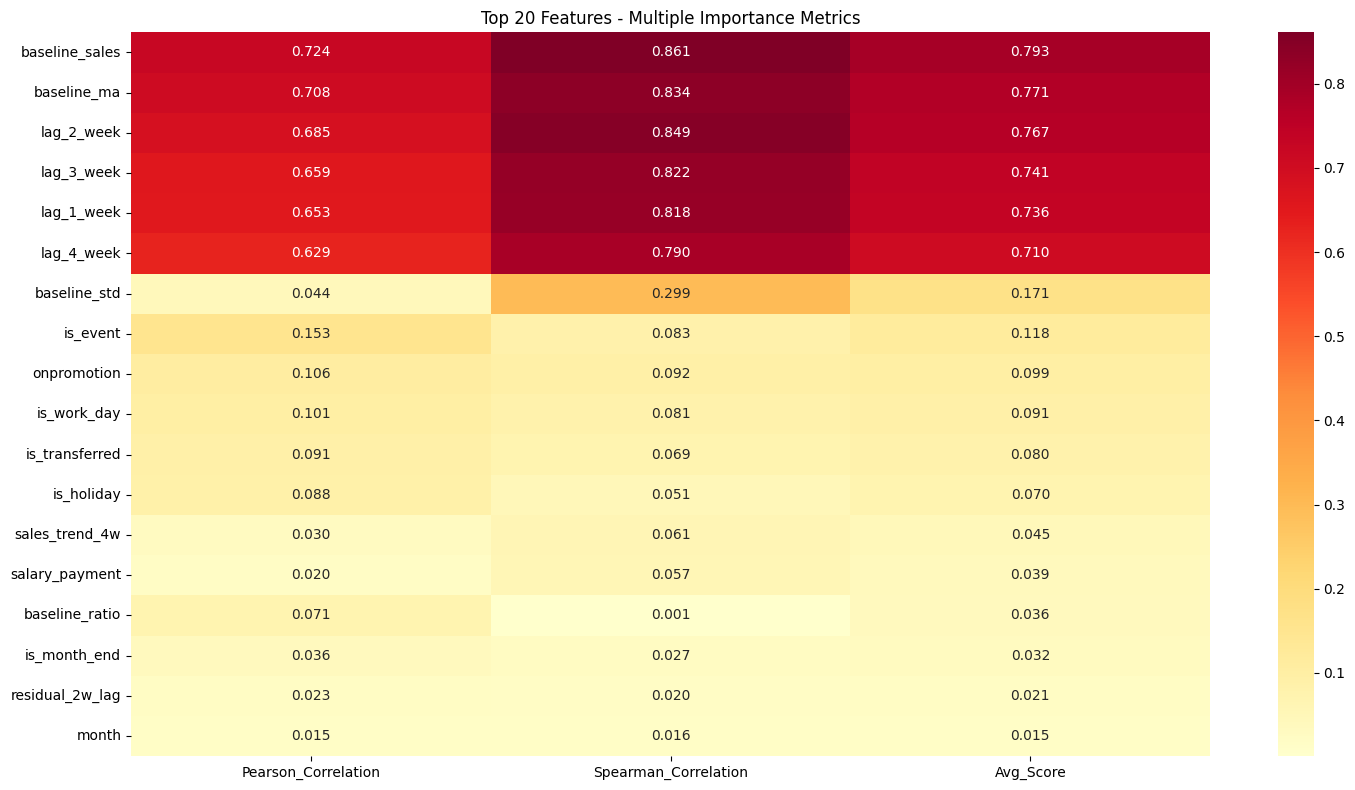


Top 15 Most Important Features Based on Average Score:
                Pearson_Correlation  Spearman_Correlation  Avg_Score
baseline_sales             0.724141              0.860996   0.792568
baseline_ma                0.708394              0.834393   0.771394
lag_2_week                 0.685263              0.848516   0.766890
lag_3_week                 0.658618              0.822460   0.740539
lag_1_week                 0.653226              0.818066   0.735646
lag_4_week                 0.629098              0.790116   0.709607
baseline_std               0.043878              0.298984   0.171431
is_event                   0.152676              0.083102   0.117889
onpromotion                0.105557              0.092452   0.099005
is_work_day                0.100539              0.080878   0.090709
is_transferred             0.090891              0.068717   0.079804
is_holiday                 0.087918              0.051166   0.069542
sales_trend_4w             0.029589            

In [516]:
# Select numeric features and target
numeric_features = df_weekly[FEATURES].select_dtypes(include=[np.number])
target = df_weekly[TARGET_2_WEEK]  # '2_week_target'

# Drop rows with NaN in either features or target
valid_idx = numeric_features.dropna().index.intersection(target.dropna().index)
X_valid = numeric_features.loc[valid_idx]
y_valid = target.loc[valid_idx]

# 1. Correlation Analysis
corr_pearson = X_valid.corrwith(y_valid)
corr_spearman = X_valid.corrwith(y_valid, method='spearman')


# Combine all metrics
feature_importance_df = pd.DataFrame({
    'Pearson_Correlation': corr_pearson.abs(),
    'Spearman_Correlation': corr_spearman.abs(),
    
})

feature_importance_df['Avg_Score'] = feature_importance_df.mean(axis=1)
feature_importance_df = feature_importance_df.sort_values('Avg_Score', ascending=False)

# Plot
plt.figure(figsize=(15, 8))
sns.heatmap(feature_importance_df.iloc[:20], annot=True, cmap='YlOrRd', fmt='.3f')
plt.title('Top 20 Features - Multiple Importance Metrics')
plt.tight_layout()
plt.show()

print("\nTop 15 Most Important Features Based on Average Score:")
print(feature_importance_df.head(15))


## validate on final test data

In [517]:
# ---------------------------
# Step 4: Prepare test data
# ---------------------------
X_test = df_test_final[FEATURES]
y_test = df_test_final[TARGET_2_WEEK]

# ---------------------------
# Step 5: Predict residuals and reconstruct final forecast
# ---------------------------
dtest = xgb.DMatrix(X_test, enable_categorical=True)

# Predict residuals
df_test_final['pred_residual'] = final_model.predict(dtest)

# Add baseline back to get final sales prediction
df_test_final['pred_xgb'] = df_test_final['pred_residual'] + df_test_final['baseline_sales']




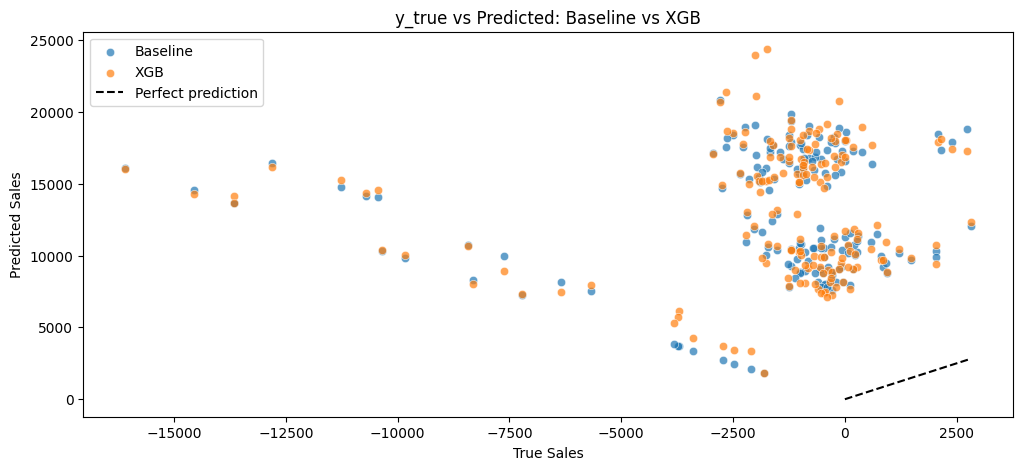

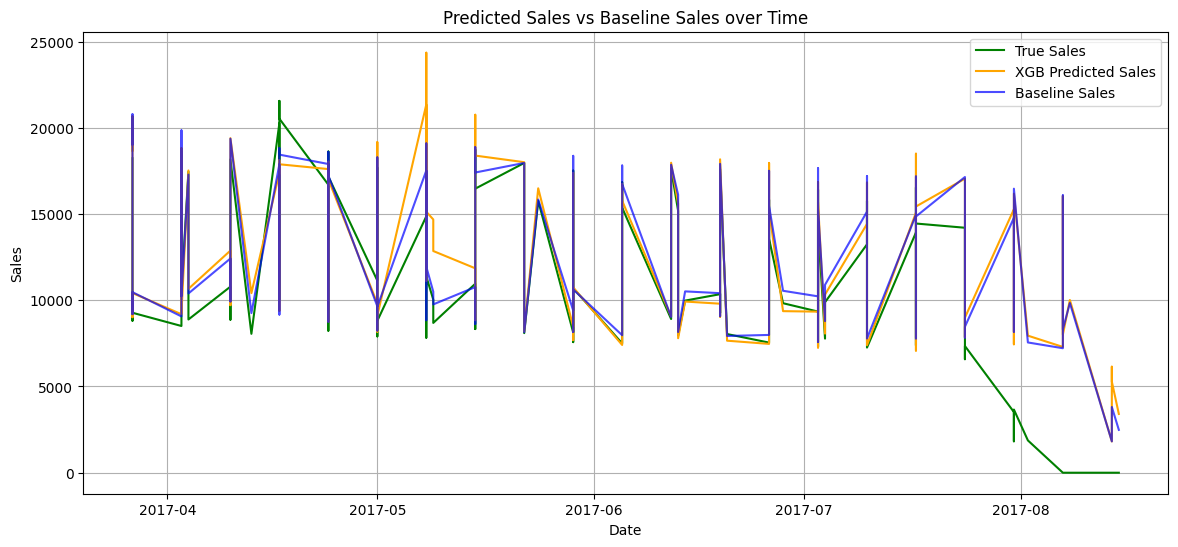

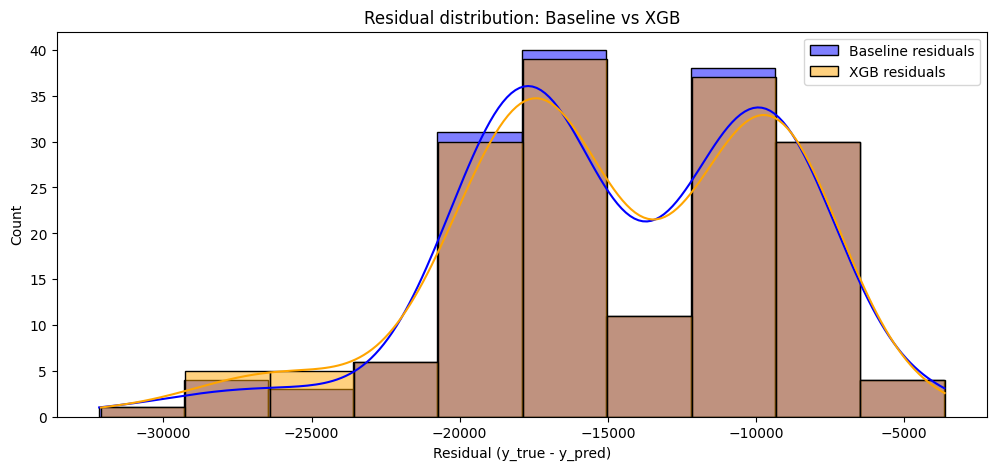

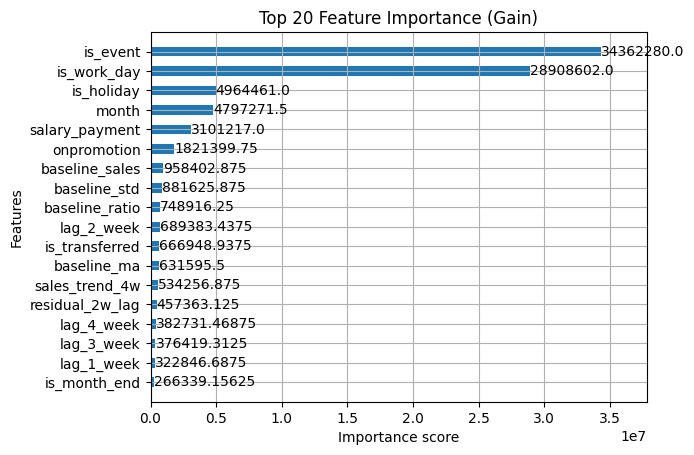

In [518]:

# -------------------------------
# 5️⃣ Plot y_true vs predictions
# -------------------------------
plt.figure(figsize=(12,5))
sns.scatterplot(x=df_test_final[TARGET], y=df_test_final['baseline_sales'], label='Baseline', alpha=0.7)
sns.scatterplot(x=df_test_final[TARGET], y=df_test_final['pred_xgb'], label='XGB', alpha=0.7)
plt.plot([0, df_test_final[TARGET].max()], [0, df_test_final[TARGET].max()], 'k--', label='Perfect prediction')
plt.xlabel('True Sales')
plt.ylabel('Predicted Sales')
plt.title('y_true vs Predicted: Baseline vs XGB')
plt.legend()
plt.show()



# Ensure your test dataframe has a proper datetime column
# Reset index completely to remove 'date' from the index
df_test_final = df_test_final.reset_index(drop=True)

# Ensure 'date' column is datetime type
df_test_final['date'] = pd.to_datetime(df_test_final['date'])

# Now sort by date safely
df_test_final = df_test_final.sort_values('date', ignore_index=True)


plt.figure(figsize=(14,6))
plt.plot(df_test_final['date'], df_test_final[TARGET_2_WEEK], label='True Sales', color='green')
plt.plot(df_test_final['date'], df_test_final['pred_xgb'], label='XGB Predicted Sales', color='orange')
plt.plot(df_test_final['date'], df_test_final['baseline_sales'], label='Baseline Sales', color='blue', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Predicted Sales vs Baseline Sales over Time')
plt.legend()
plt.grid(True)
plt.show()


# -------------------------------
# 6️⃣ Residual plots
# -------------------------------
df_test_final['residual_baseline'] = df_test_final[TARGET] - df_test_final['baseline_sales']
df_test_final['residual_xgb'] = df_test_final[TARGET] - df_test_final['pred_xgb']

plt.figure(figsize=(12,5))
sns.histplot(df_test_final['residual_baseline'], color='blue', label='Baseline residuals', kde=True)
sns.histplot(df_test_final['residual_xgb'], color='orange', label='XGB residuals', kde=True)
plt.title('Residual distribution: Baseline vs XGB')
plt.xlabel('Residual (y_true - y_pred)')
plt.legend()
plt.show()




# -------------------------------
# 7️⃣ Feature importance from XGBoost
# -------------------------------
xgb.plot_importance(final_model, max_num_features=20, importance_type='gain', height=0.5)
plt.title('Top 20 Feature Importance (Gain)')
plt.show()

### Calculate performance metrics for the weekly predictions of next week

##### Calculate performance metrics for the weekly predictions of the next ISO-week at store level. This performance evaluation is relevant for the warehouse manager

In [519]:


metrics_combined = f_metrics_weekly(
    df_test_final,
    y_true_col='2_week_target',
    y_pred_cols=['pred_xgb', 'baseline_sales']
)

print(metrics_combined)




                       weeks      prediction     rmse      mae   mape    rae  \
0         2017-W21, 2017-W22        pred_xgb   712.32   487.82   3.61   3.80   
1         2017-W21, 2017-W22  baseline_sales   875.81   664.17   5.59   5.18   
2         2017-W23, 2017-W24        pred_xgb   496.93   365.32   2.78   2.91   
3         2017-W23, 2017-W24  baseline_sales   752.14   649.86   5.00   5.17   
4         2017-W25, 2017-W26        pred_xgb   876.45   639.23   4.80   5.19   
5         2017-W25, 2017-W26  baseline_sales  1025.24   778.08   6.30   6.31   
6         2017-W27, 2017-W28        pred_xgb  1071.76   814.17   6.29   7.00   
7         2017-W27, 2017-W28  baseline_sales  1278.78  1090.85   9.10   9.37   
8         2017-W29, 2017-W30        pred_xgb  1685.56  1418.24  12.77  12.37   
9         2017-W29, 2017-W30  baseline_sales  1424.76  1134.71  10.52   9.90   
10  Average (2-week rolling)  baseline_sales  1071.35   863.53   7.30   7.19   
11  Average (2-week rolling)        pred

### analyze_predictions

C:\Users\jasmi\AppData\Local\Temp\ipykernel_32072\364787356.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample)


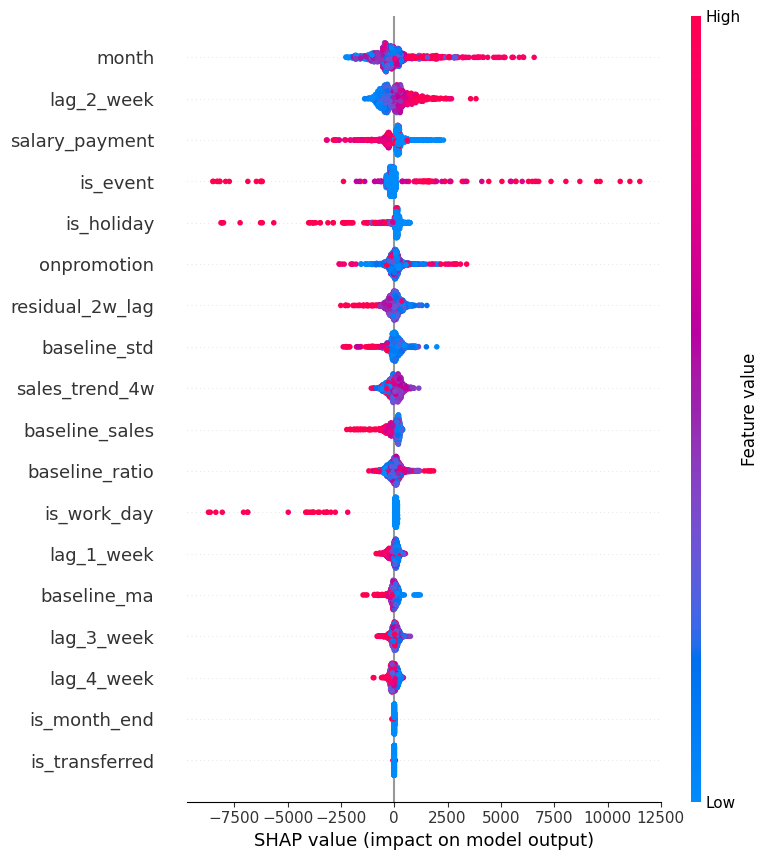

In [520]:
import shap

explainer = shap.TreeExplainer(final_model)
X_sample = df_trainval[FEATURES].sample(
    n=min(2000, len(df_trainval)),  # take up to 2000 rows max
    random_state=42
)

shap_values = explainer(X_sample)

shap.summary_plot(shap_values, X_sample)


## 8. Plot Forecasts - BASELINE, XGB


Plot total daily, weekly, and monthly forecasts using matplotlib for visual inspection.

In [521]:
def plot_forecast(df_forecast, date_col='date', value_col='pred_xgb', title='Forecast'):
    plt.figure(figsize=(12, 5))
    plt.plot(df_forecast[date_col], df_forecast[value_col], marker='o')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

# Plot total daily forecast
plot_forecast(daily_forecast_xgb.groupby('date')['pred_xgb'].sum().reset_index(), title='Total Daily Forecast (sum all stores/items)')

# Plot weekly forecast
plot_forecast(weekly_forecast_2weeks_xgb, date_col='week', title='Weekly Forecast (per store)')

# Plot monthly forecast
plot_forecast(monthly_forecast_2months_xgb, date_col='month', title='Monthly Forecast (per item)')

NameError: name 'daily_forecast_xgb' is not defined

## 8.2 Plot Daily Total Sales + Forecasts - BASELINE, XGB

In [ ]:
# Plot total sales: actuals (train/test), test predictions, and forecast

train_total = df_trainval.groupby('date')['unit_sales'].sum().reset_index()
test_total = df_test_final.groupby('date')[['unit_sales', 'pred_lgb']].sum().reset_index()
forecast_total = daily_forecast_xgb.groupby('date')['pred_lgb'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(train_total['date'], train_total['unit_sales'], label='Train Actual', color='blue')
plt.plot(test_total['date'], test_total['unit_sales'], label='Test Actual', color='green')
plt.plot(test_total['date'], test_total['pred_xgb'], label='Test Prediction (XGB)', color='orange')
plt.plot(forecast_total['date'], forecast_total['pred_xgb'], label='7-Day Forecast (XGB)', color='red', marker='o')

plt.title('Total Sales: Actuals, Predictions, and 7-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 8.3 Plot Daily Total Sales + Forecasts for an ITEM/STORE combination - BASELINE, XGB

In [ ]:
# Plot actuals and predictions for train, test, and forecast for a single store/item
from datetime import datetime
store_id = 44
item_id = 1971328

# Get data for this store/item
df_train = df_trainval[(df_trainval['store_nbr'] == store_id) & (df_trainval['item_nbr'] == item_id)].copy()
df_test = df_test_final[(df_test_final['store_nbr'] == store_id) & (df_test_final['item_nbr'] == item_id)].copy()
df_forecast_xgb = daily_forecast_xgb[(daily_forecast_xgb['store_nbr'] == store_id) & (daily_forecast_xgb['item_nbr'] == item_id)].copy()
df_train = df_train.reset_index().copy()
df_test = df_test.reset_index().copy()
df_forecast_xgb = df_forecast_xgb.reset_index().copy()

plt.figure(figsize=(14, 6))


plt.plot(df_train['date'], df_train['unit_sales'], label='Train Actual', color='blue')
plt.plot(df_test['date'], df_test['unit_sales'], label='Test Actual', color='green')
plt.plot(df_test['date'], df_test['pred_xgb'], label='Test Prediction (XGB)', color='orange')
plt.plot(df_forecast_xgb['date'], df_forecast_xgb['pred_xgb'], label='7-Day Forecast (XGB)', color='red', marker='o')

plt.title(f'Store {store_id}, Item {item_id}: Actuals, Predictions, and Forecast')
plt.xlabel('Date')
plt.xlim(left=datetime(2017, 3, 1), right=datetime(2017,11,1) )
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 9. Save Forecast Outputs

Save the daily, weekly, and monthly forecast DataFrames to CSV files for downstream use.

In [ ]:
daily_forecast_xgb.to_csv('../data/daily_forecast_xgb.csv', index=False)
weekly_forecast_2weeks_xgb.to_csv('../data/weekly_forecast_xgb.csv', index=False)
monthly_forecast_2months_xgb.to_csv('../data/monthly_forecast_xgb.csv', index=False)



In [ ]:
# Analyze feature correlations and importance
print("Feature correlations with target (unit_sales):")
correlations = df_model[WEEKLY_FEATURES + [TARGET]].corr()[TARGET].sort_values(ascending=False)
print(correlations.to_string())

print("\nFeature correlations with baseline_ratio:")
baseline_corr = df_model[WEEKLY_FEATURES].corrwith(df_model['baseline_ratio']).sort_values(ascending=False)
print(baseline_corr.to_string())

# Check data distribution before/after transformation
if 'baseline_ratio' in df_model.columns and 'log_baseline_ratio' in df_model.columns:
    print("\nBaseline ratio stats:")
    print(df_model['baseline_ratio'].describe())
    print("\nlog_baseline_ratio stats:")
    print(df_model['log_baseline_ratio'].describe())

    # Check if we have any extreme values that might be affecting the model
    print("\nExtreme values check:")
    print(f"Values > 10x baseline: {(df_model['baseline_ratio'] > 10).sum():,} records")
    print(f"Values < 0.1x baseline: {(df_model['baseline_ratio'] < 0.1).sum():,} records")

# Print correlation matrix heatmap data
print("\nFeature correlation matrix:")
correlation_matrix = df_model[WEEKLY_FEATURES].corr().round(3)
print(correlation_matrix.to_string())